In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit.circuit import ParameterVector

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, LeakyReLU

import sys
sys.path.insert(1, '/home/fredo/qgan-lamarr/qgan_tests')
from distributions import MinMaxBinning, SingleGaussian
from qgan import QGAN

2026-04-14 20:24:13.218923: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 20:24:13.237068: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776191053.257367 1167623 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776191053.262957 1167623 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776191053.280626 1167623 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# Distribution

{'000': 29, '001': 83, '010': 239, '011': 302, '100': 237, '101': 98, '110': 27, '111': 9}


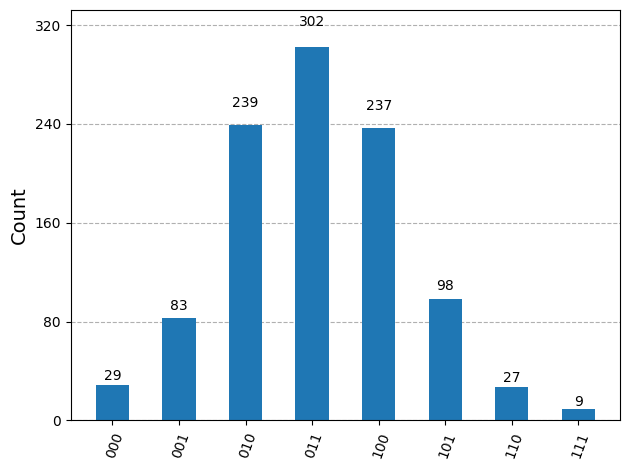

In [2]:
num_qubits = 3
nbins = 2**num_qubits

def sample_dist(_size, _nbins):
    _sample = SingleGaussian(shots = _size)
    return MinMaxBinning(_sample, _nbins)

sample = sample_dist(2**10, nbins)
print(sample)
plot_histogram(sample)

# QGAN networks

In [3]:
def build_gen(num_qubits, reps=2):
    qc = QuantumCircuit(num_qubits)
    qc.h(range(num_qubits))
    theta = ParameterVector("θ", length = (reps + 1) * num_qubits * 2)
    p = 0
    for q in range(num_qubits):
            qc.ry(theta[q], q)
            p += 1
    for r in range(reps):
        for q in range(num_qubits):
            qc.cz(q%num_qubits, (q + 1)%num_qubits)
        for q in range(num_qubits):
            qc.ry(theta[p], q)
            p += 1
    return qc
    
def build_dis(num_qubits):
    nbins = 2**num_qubits
    discriminator = Sequential([InputLayer(shape=(nbins,)),
                                Dense(50),
                                LeakyReLU(),
                                Dense(1, activation='sigmoid')])
    return discriminator

def build_model(num_qubits, sample_dist):
    model = QGAN(num_qubits = num_qubits,
                 generator = build_gen(num_qubits, reps = 2),
                 discriminator = build_dis(num_qubits),
                 real_dist = sample_dist)
    return model

In [6]:
model = build_model(num_qubits, sample_dist)
epochs = 4000
model.discriminator_lr = 1e-2
model.fit(epochs = epochs, shots = 2**10, step_balance = 1, manager = True, opt = 'ADAM_PSR', lr = 1e-3)

Monitoring run: run_20260414_210519
Training started


100%|██████████| 4000/4000 [11:48<00:00,  5.64it/s]

Training completed


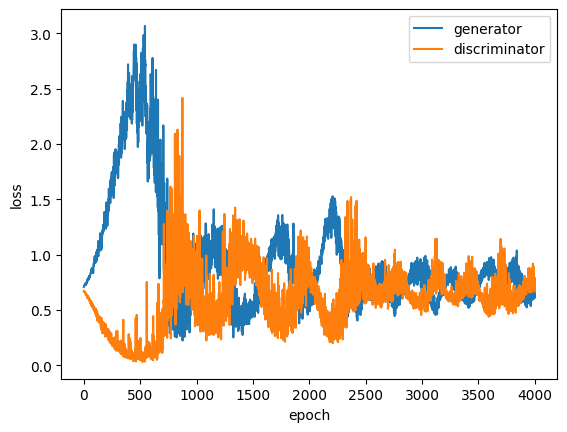

In [7]:
plt.plot(model.generator_losses, label = 'generator')
plt.plot(model.discriminator_losses, label = 'discriminator')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()